# RNN


## RNN 结构
使用潜变量 $h_t$ 总结过去信息 $$p(h_t|h_{t-1},x_{t-1})$$ $$p(x_t|h_t, x_{t-1})$$

![rnn](./images/rnn.svg)

- 隐藏状态更新 $$h_t = f(h_{t-1}, x_{t-1}) = \sigma(W_{hh} h_{t-1} + W_{xh} x_{t-1} + b_h)$$
- 输出 $$y_t = g(h_t) = \sigma(W_{hy} h_t + b_y)$$

## 困惑度
衡量语言模型的好坏可以用平均交叉熵，其中 $p$ 是预测概率，$x_t$ 是真实词
$$\pi = \cfrac{1}{n} \sum_{i=1}^n -\log p(x_t|x_{t-1}\ldots)$$

困惑度 $$\text{perplexity} = e^{\pi}$$
- $e^0=1$ 表示完美预测
- $e^{\log V} = V$ 表示随机预测，其中 $V$ 是词表大小

## 梯度剪裁
迭代计算 $T$ 个时间步的梯度，反向转播产生 $O(T)$ 的乘法链，要么很大要么很小。
- 梯度长度超过阈值 $\theta$，则投影回到阈值球面上 $$g'=\min(\cfrac{\theta}{||g||},1)g$$

> 也可以通过稳定初始化的方式缓解


## 从零实现


In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
import util
import typing

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


获取数据


In [2]:
batch_size = 32 # 批量大小
num_steps = 35 # 时间步数
train_iter, vocab = util.data.load_data_time_machine(batch_size, num_steps)

独热编码


In [3]:
F.one_hot(torch.tensor([0, 2]), len(vocab)) # (2, V)

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

小批量数据的形状


In [4]:
X = torch.arange(10).reshape((2, 5)) # (B, T)
F.one_hot(X.T, len(vocab)).shape # (T, B, V)

torch.Size([5, 2, 28])

初始化 RNN 参数


In [5]:
def get_params(vocab_size, num_hiddens, device):
    # 输入和输出的维度都是词表大小，因为用 one-hot 编码了
    num_inputs = num_outputs = vocab_size
    def normal(shape):
        """生成指定形状的均值 0 方差 0.01 的正态分布随机张量"""
        return torch.randn(size=shape, device=device) * 0.01
    # 隐藏层参数
    W_xh = normal((num_inputs, num_hiddens)) # x1 -> h2
    W_hh = normal((num_hiddens, num_hiddens)) # h1 -> h2
    b_h = torch.zeros(num_hiddens, device=device) # h 上的偏置
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs)) # h1 -> y1
    b_q = torch.zeros(num_outputs, device=device) # y 上的偏置
    # 附上梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

需要初始隐藏状态


In [6]:
def init_rnn_state(batch_size, num_hiddens, device):
    """初始化隐藏状态"""
    # 全 0，形状 (B, H)。放在 tuple 里为了和后续 LSTM 统一接口
    return (torch.zeros((batch_size, num_hiddens), device=device), )

定义一个时间步内计算 h 和 y


In [7]:
def rnn(inputs, state, params):
    """RNN 前向计算
    inputs: (T, B, V)
    state: tuple: (H),
    params: (W_xh, W_hh, b_h, W_hq, b_q)
    """
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state # 取出隐藏状态
    outputs = []
    for X in inputs: # 遍历时间步
        # 按公式计算，tanh 激活
        H = torch.tanh(torch.mm(X, W_xh) + # X 是当前时刻输入
                       torch.mm(H, W_hh) + # 此时 H 还是前一个时刻的隐藏状态
                       b_h) # 更新 H 为新隐藏状态
        Y = torch.mm(H, W_hq) + b_q # 计算输出 (B, V)
        outputs.append(Y)
    # cat (B, V) -> (T*B, V)，是 T 个矩阵竖着拼在一起
    return torch.cat(outputs, dim=0), (H,) # 所有输出, 最后的隐藏状态

创建类包装这些函数


In [8]:
class RNNModelScratch:
    """从零实现的循环神经网络模型"""
    def __init__(self,
                 vocab_size: int,
                 num_hiddens: int,
                 device: torch.device,
                 get_params: typing.Callable,
                 init_state: typing.Callable,
                 forward_fn: typing.Callable):
        """初始化循环神经网络模型
        :param vocab_size: 词表大小
        :param num_hiddens: 隐藏层大小
        :param device: 设备
        :param get_params: 获取参数的函数 (vocab_size, num_hiddens, device) -> params
        :param init_state: 初始化隐藏状态的函数 (batch_size, num_hiddens, device) -> state
        :param forward_fn: 前向计算的函数 (inputs, state, params) -> (outputs, state)
        """
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X: torch.Tensor, state: tuple):
        """前向计算
        :param X: 输入 token id 序列 (B, T)
        :param state: 隐藏状态 (H)
        :return: 输出竖拼接 (T*B, V), 隐藏状态 (H)
        """
        X = F.one_hot(X.T.long(), self.vocab_size).type(torch.float32) # one-hot 编码成 (T, B, V)
        return self.forward_fn(X, state, self.params) # 调用 rnn 函数计算输出和隐藏状态

    def begin_state(self, batch_size: int, device: torch.device):
        """初始化隐藏状态
        :param batch_size: 批量大小
        :param device: 设备
        :return: 隐藏状态 (H)
        """
        return self.init_state(batch_size, self.num_hiddens, device)

检查形状是否正确


In [9]:
num_hiddens = 512
device = util.try_gpu()
net = RNNModelScratch(len(vocab),
                      num_hiddens,
                      device,
                      get_params,
                      init_rnn_state,
                      rnn)
state = net.begin_state(X.shape[0], device)
Y, new_state = net(X.to(device), state)
print(Y.shape) # (T*B, V)
print(new_state[0].shape) # (B, H)

torch.Size([10, 28])
torch.Size([2, 512])


定义根据前缀继续生成的函数


In [10]:
def predict_ch8(prefix: str, num_preds: int, net, vocab: util.Vocab, device: torch.device):
    """根据前缀 prefix 生成后续的 num_preds 个字符
    :param prefix: 前缀字符串
    :param num_preds: 预测的字符数
    :param net: 循环神经网络模型
    :param vocab: 词表
    :param device: 设备
    :return: 生成的字符串
    """
    # 获取当前输入的函数
    get_input = lambda: torch.tensor([[outputs[-1]]], device=device).reshape(1, 1) # 取最后一次输出
    # 将 prefix 转换为 token id 序列
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]] # 输出列表，先放入第一个字符的 id
    for y in prefix[1:]: # 遍历前缀的剩余字符
        y_hat, state = net(get_input(), state) # 前向计算，更新隐藏状态
        outputs.append(vocab[y]) # 将当前字符的 id 加入输出列表
    for y in range(num_preds): # 生成后续字符
        y_hat, state = net(get_input(), state) # 前向计算，更新隐藏状态
        outputs.append(int(y_hat.argmax(dim=1).reshape(1))) # 取最大概率的字符 id 加入输出列表
    return ''.join([vocab.idx_to_token[i] for i in outputs]) # 将 id 转换为字符并拼接成字符串

试一下


In [11]:
predict_ch8('time traveller ', 10, net, vocab, device)

'time traveller u<unk>npx u<unk>do'

剃度剪裁


In [12]:
def grad_clipping(net, theta: float):
    """裁剪梯度
    :param net: 循环神经网络模型
    :param theta: 阈值
    :param device: 设备
    """
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad] # 获取需要梯度的参数
    else:
        params = net.params # 如果是自定义模型，直接取 params
    # 计算梯度的 L2 范数，所有参数的梯度平方和开根
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta: # 如果范数超过阈值
        for param in params:
            # 按比例缩放梯度
            param.grad[:] *= theta / norm # [:] 表示 inplace

定义训练函数


In [13]:
def train_epoch_ch8(net, train_iter, loss, updater, device: torch.device, use_random_iter: bool):
    """训练一个迭代周期
    :param net: 循环神经网络模型
    :param train_iter: 训练数据迭代器
    :param loss: 损失函数
    :param updater: 优化器
    :param device: 设备
    :param use_random_iter: 是否使用随机采样
    :return: 平均困惑度，训练速度
    """
    state, timer = None, util.Timer()
    metric = util.Accumulator(2) # 累加总损失和总词数
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 初始化隐藏状态，随机采样时每个小批量都重新初始化
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            # 如果是顺序采样，使用上一个小批量的隐藏状态，并将其从前面的计算图中分离出来
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state:
                    s.detach_()
        X, Y = X.to(device), Y.to(device)
        y = Y.T.reshape(-1) # 将标签 (T, B) 展平为 (T*B,)
        y_hat, state = net(X, state) # 前向计算
        l = loss(y_hat, y.long()).mean() # 计算损失
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1) # 梯度裁剪
            updater.step()
        else:
            l.backward() # 自定义优化器，直接调用 backward
            grad_clipping(net, 1)
            updater(batch_size=1) # 更新参数，传入批量大小为 1，因为已经在 loss 中取了平均
        metric.add(l * y.numel(), y.numel()) # 累加总损失和总词数
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop() # 平均困惑度, 训练速度

In [14]:
def train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):
    """训练模型
    :param net: 循环神经网络模型
    :param train_iter: 训练数据迭代器
    :param vocab: 词表
    :param lr: 学习率
    :param num_epochs: 迭代周期数
    :param device: 设备
    :param use_random_iter: 是否使用随机采样
    """
    loss = nn.CrossEntropyLoss() # 定义交叉熵损失函数
    animator = util.Animator(xlabel='epoch', ylabel='perplexity', legend=['train'], xlim=[10, num_epochs]) # 绘制困惑度曲线
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr=lr) # 使用 PyTorch 的优化器
    else:
        updater = lambda batch_size: util.train.sgd(net.params, lr, batch_size) # 自定义优化器
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device) # 预测 50 个字
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller '))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} token/秒, 设备 {str(device)}')
    print(f'预测: {predict("time traveller ")}')
    print(f'预测: {predict("traveller ")}')

开始训练


困惑度 9.5, 171051.7 token/秒, 设备 cuda:0
预测: time traveller thesuin these a meressing these a meressing these 
预测: traveller a mad some i heress a corlong i was a couress a me


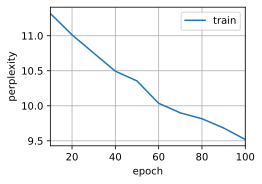

In [18]:
num_epochs = 100
lr = 0.5
train_ch8(net, train_iter, vocab, lr, num_epochs, device)

再看一下随机抽样的效果


困惑度 9.2, 169798.5 token/秒, 设备 cuda:0
预测: time traveller the more the more the more the more the more the m
预测: traveller of me tho gould thingsed thingsed thingsed thingse


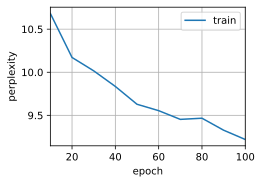

In [19]:
train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=True)

## 简洁实现


定义模型


In [20]:
rnn_layer = nn.RNN(input_size=len(vocab), hidden_size=num_hiddens) # RNN 层
# 初始隐藏状态，(num_layers * num_directions, B, H)
state = torch.zeros((1, batch_size, num_hiddens)) 

尝试使用


In [21]:
X = torch.rand(num_steps, batch_size, len(vocab)) # (T, B, V)
Y, state_new = rnn_layer(X, state) # 前向计算
Y.shape, state_new.shape # (T, B, H), (num_layers * num_directions, B, H)

(torch.Size([35, 32, 512]), torch.Size([1, 32, 512]))


完整模型


In [22]:
class RNNModel(nn.Module):
    """循环神经网络模型"""
    def __init__(self, rnn_layer, vocab_size: int):
        """
        :param rnn_layer: RNN 层
        :param vocab_size: 词表大小
        """
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = rnn_layer.hidden_size
        # 如果是双向 RNN，则 num_directions = 2，否则为 1
        self.num_directions = 1 + rnn_layer.bidirectional
        # 输出层，将 RNN 的输出映射到词表大小的维度
        self.linear = nn.Linear(self.num_directions * self.num_hiddens, self.vocab_size)

    def forward(self, X: torch.Tensor, state: torch.Tensor):
        """前向计算
        :param X: 输入 token id 序列 (B, T)
        :param state: 隐藏状态 (num_layers * num_directions, B, H)
        :return: 输出竖拼接 (T*B, V), 隐藏状态 (num_layers * num_directions, B, H)
        """
        X = F.one_hot(X.T.long(), self.vocab_size).type(torch.float32) # one-hot 编码成 (T, B, V)
        Y, state = self.rnn(X, state) # 前向计算
        output = self.linear(Y.reshape(-1, Y.shape[-1])) # 输出层，(T*B, V)
        return output, state

    def begin_state(self, batch_size: int, device: torch.device):
        """初始化隐藏状态
        :param batch_size: 批量大小
        :param device: 设备
        :return: 隐藏状态 (num_layers * num_directions, B, H)
        """
        if not isinstance(self.rnn, nn.LSTM):
            # 如果是 RNN 或 GRU，返回全 0 的隐藏状态
            return torch.zeros((self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens), device=device)
        else:
            # 如果是 LSTM，返回全 0 的隐藏状态和细胞状态
            return (torch.zeros((self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens), device=device),
                    torch.zeros((self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens), device=device))

训练模型，框架对矩阵乘法的并行优化更好所以快


困惑度 3.0, 597584.1 token/秒, 设备 cuda:0
预测: time traveller sact and the reflocies were the hall was all i was
预测: traveller i was so to a methed myself thesund the was of the


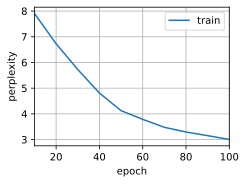

In [23]:
train_ch8(RNNModel(rnn_layer, len(vocab)).to(device), train_iter, vocab, lr, num_epochs, device)